In [3]:
# Haetaan peruskirjastot
import pandas as pd
import numpy as np

# Tiedostojenkäsittely useaa CSV:tä varten
import os
import glob

# Visualisointi
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from PIL import Image

# Aikavyöhykkeet ja aikaleimakäsittely
from datetime import datetime

In [23]:
# Hakemistot
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)

raw_path = os.path.join(project_root, "data", "raw")
processed_path = os.path.join(project_root, "data", "processed")

# Store config
import sys
sys.path.append(os.path.join(project_root, "config"))
from store_config import store_config

# Tiedostot
raw_files = sorted(glob.glob(os.path.join(raw_path, "*.csv")))
processed_files = sorted(glob.glob(os.path.join(processed_path, "*.parquet")))

# Myymäläalueen koordinaattiarvot
store_max_x = store_config["geometry"]["store_max_x_cm"]
store_max_y = store_config["geometry"]["store_max_y_cm"]

print(f"Nykyinen hakemisto: {current_dir}")
print(f"Raw-tiedostoja: {len(raw_files)}")
print(f"Processed-tiedostoja: {len(processed_files)}")
print(f"Myymälän koko: {store_max_x} x {store_max_y} cm")

Nykyinen hakemisto: /home/suviniemittm25sai/code/projektiopinnot-1-datan-hallinta-laitetaan-parastamme/notebooks
Raw-tiedostoja: 31
Processed-tiedostoja: 21
Myymälän koko: 11206 x 5220 cm


In [24]:
# Poistetut ja säilytetyt kärryt
raw_nodes = set(os.path.basename(f).replace(".csv", "") for f in raw_files)
processed_nodes = set(os.path.basename(f).replace(".parquet", "") for f in processed_files)

missing_nodes = sorted(raw_nodes - processed_nodes)
kept_nodes = sorted(raw_nodes - set(missing_nodes))

print(f"Poistetut kärryt: {len(missing_nodes)}")
print(f"Säilytetyt kärryt: {len(kept_nodes)}")

Poistetut kärryt: 10
Säilytetyt kärryt: 21


### 1. Tutkitaan raakadatan perusominaisuuksia

In [25]:
summary = []

for f in raw_files:
    node_name = os.path.basename(f).replace(".csv", "")
    df = pd.read_csv(
        f,
        dtype={"node_id": str, "timestamp": str, "x": float, "y": float, "z": float, "q": float}
    )
    
    total = len(df)
    duplicates = df.duplicated().sum()
    outside = ((df["x"] < 0) | (df["x"] > store_max_x) |
               (df["y"] < 0) | (df["y"] > store_max_y)).sum()
    
    summary.append({
        "node": node_name,
        "rivejä": total,
        "duplikaatit": duplicates,
        "koordinaatit_ulkopuolella": outside,
        "ulkona_%": round(outside / total * 100, 1),
        "x_min": df["x"].min(),
        "x_max": df["x"].max(),
        "y_min": df["y"].min(),
        "y_max": df["y"].max(),
        "q_mean": round(df["q"].mean(), 1)
    })
    
    del df  # vapautetaan muisti heti

summary_df = pd.DataFrame(summary)
print(f"Kärryjä yhteensä: {len(summary_df)}")
print(f"Rivejä yhteensä: {summary_df['rivejä'].sum():,}")
print()
print(summary_df.to_string(index=False))

Kärryjä yhteensä: 31
Rivejä yhteensä: 139,961,560

      node  rivejä  duplikaatit  koordinaatit_ulkopuolella  ulkona_%    x_min   x_max    y_min    y_max  q_mean
 node_3200 6489294            0                    1095425      16.9 -32818.0 32655.0 -32705.0  32706.0    64.8
 node_3224 6136400            0                    1580180      25.8 -32818.0 32711.0 -32645.0  32403.0    62.7
 node_3240 6329160            0                    1025707      16.2 -32813.0 32708.0 -32701.0  32389.0    70.9
node_42787       8            0                          3      37.5 -32818.0 32716.0 -32718.0   3602.0   147.1
node_45300       1            0                          1     100.0  30197.0 30197.0   2395.0   2395.0    70.0
node_51719 9316264            0                    1780239      19.1 -32811.0 32609.0 -32705.0  32663.0    62.0
node_51720     216            0                         19       8.8 -23730.0  9714.0 -21336.0   3668.0    51.5
node_51735 4903274            0                     8

### Havainnot

Datamäärät:
- Kärryt joissa eniten dataa: node_51719 (9.3M riviä), node_52535 (9.0M riviä)
- Kärryt, joissa vähiten dataa: node_42787 (8), node_45300 (1), node_64458 (1)

Koordinaatit:
- Lähes kaikilla kärryillä on datapisteitä x ja y -koordinaateissa ±32000 eli kaukana myymälän ulkopuolella

Duplikaatit:
- Ei duplikaatteja yhdelläkään kärryllä

### 2. Tutkitaan miten data jakautuu ajallisesti

In [5]:
# Tutkitaan ajallinen jakauma
time_summary = []

for f in raw_files:
    node_name = os.path.basename(f).replace(".csv", "")
    df = pd.read_csv(
        f,
        dtype={"node_id": str, "timestamp": str, "x": float, "y": float, "z": float, "q": float}
    )
    
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    
    time_summary.append({
        "node": node_name,
        "rivejä": len(df),
        "aikaisin": df["timestamp"].min(),
        "myöhäisin": df["timestamp"].max(),
        "päiviä": (df["timestamp"].max() - df["timestamp"].min()).days
    })
    
    del df

time_df = pd.DataFrame(time_summary)
print(time_df.to_string(index=False))

      node  rivejä                         aikaisin                        myöhäisin  päiviä
 node_3200 6489294 2019-03-07 11:46:19.078016+00:00 2020-01-22 17:53:46.479008+00:00     321
 node_3224 6136400 2019-03-07 11:43:48.077950+00:00 2020-01-23 11:28:26.478905+00:00     321
 node_3240 6329160 2019-03-07 13:04:49.079971+00:00 2020-01-23 10:00:05.479023+00:00     321
node_42787       8 2019-03-22 13:39:51.694419+00:00 2019-12-30 08:17:58.478784+00:00     282
node_45300       1 2019-12-30 08:28:01.478941+00:00 2019-12-30 08:28:01.478941+00:00       0
node_51719 9316264 2019-03-07 13:05:17.078153+00:00 2020-01-23 12:42:52.479028+00:00     321
node_51720     216 2019-03-22 00:56:13.687866+00:00 2020-01-12 13:06:11.470926+00:00     296
node_51735 4903274 2019-03-06 15:32:26.078541+00:00 2020-01-23 12:47:30.479339+00:00     322
node_51751 7706871 2019-03-06 15:30:09.078043+00:00 2020-01-23 12:47:54.479298+00:00     322
node_51850 7479609 2019-03-06 15:31:16.077947+00:00 2020-01-23 12:49:5

### Havainnot

Aikaväli
- Suurin osa kärryistä on liikkunut aikavälillä maaliskuu 2019 – tammikuu 2020 eli noin 10 kuukautta
- Kaikilla siivouksen läpäisseillä kärryillä hyvin yhtenäinen aikaväli 300–322 päivää

Siivouksessa poistetut kärryt erottuvat selvästi:
- node_45300 ja node_64458 → 0 päivää, vain yksi piste, selvästi viallinen sensori
- node_42787 ja node_53000 → data alkaa myöhemmin kuin muilla (22.3.2019). Sensori otettu käyttöön myöhemmin tai vioittunut

Mielenkiintoinen havainto
- node_51866 data loppuu 4.1.2020, muut jatkavat 23.1.2020 asti → sensori on todennäköisesti hajonnut tai poistettu käytöstä aiemmin
- node_51992 ja node_52003: data loppuu myös aiemmin

### 3. Visualisoidaan datan ajallinen jakautuma

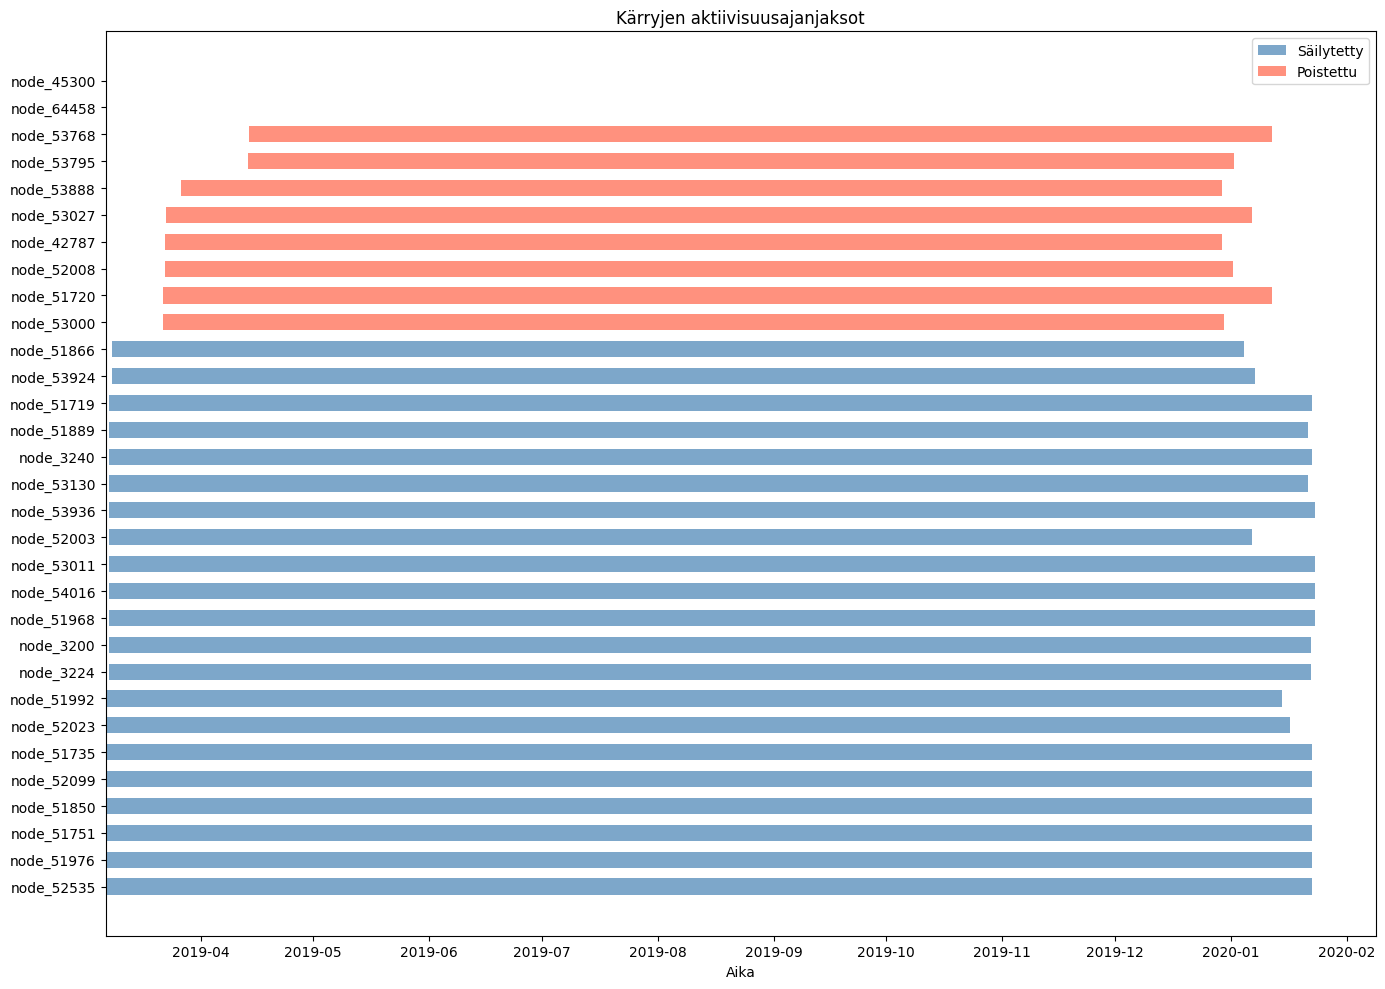

In [8]:
fig, ax = plt.subplots(figsize=(14, 10))

# Järjestetään kärryt alkamisajan mukaan
time_df_sorted = time_df.sort_values("aikaisin")

# Piirretään jana jokaiselle kärrylle
for i, row in enumerate(time_df_sorted.itertuples()):
    color = "tomato" if row.node in missing_nodes else "steelblue"
    ax.barh(row.node, 
            (row.myöhäisin - row.aikaisin).days, 
            left=row.aikaisin, 
            color=color, 
            alpha=0.7,
            height=0.6)

# Selite
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="steelblue", alpha=0.7, label="Säilytetty"),
    Patch(facecolor="tomato", alpha=0.7, label="Poistettu")
]
ax.legend(handles=legend_elements)

ax.set_xlabel("Aika")
ax.set_title("Kärryjen aktiivisuusajanjaksot")
plt.tight_layout()
plt.show()

### 4. Visualisoidaan raakadatan koordinaattijakauma

Pisteitä myymälän sisällä: 136,630,143


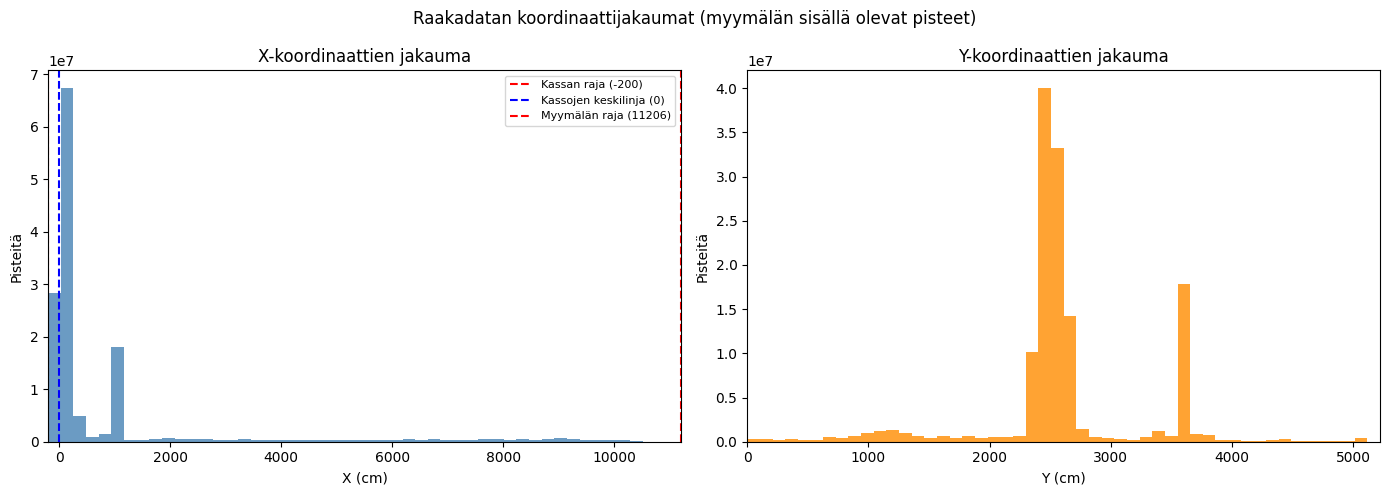

In [26]:
# Lasketaan histogrammiarvot tiedosto kerrallaan
bins_x = np.linspace(-200, store_max_x, 51)  # 50 pylvästä
bins_y = np.linspace(0, store_max_y, 51)

counts_x = np.zeros(50)
counts_y = np.zeros(50)
total_inside = 0

for f in raw_files:
    df = pd.read_csv(
        f,
        usecols=["x", "y"],  # ladataan vain x ja y
        dtype={"x": float, "y": float}
    )
    
    inside = df[
        (df["x"] >= -200) & (df["x"] <= store_max_x) &
        (df["y"] >= 0) & (df["y"] <= store_max_y)
    ]
    
    counts_x += np.histogram(inside["x"], bins=bins_x)[0]
    counts_y += np.histogram(inside["y"], bins=bins_y)[0]
    total_inside += len(inside)
    
    del df, inside

print(f"Pisteitä myymälän sisällä: {total_inside:,}")

# Piirretään
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(bins_x[:-1], counts_x, width=np.diff(bins_x), color="steelblue", alpha=0.8, align="edge")
axes[0].axvline(-200, color="red", linestyle="--", lw=1.5, label="Kassan raja (-200)")
axes[0].axvline(0, color="blue", linestyle="--", lw=1.5, label="Kassojen keskilinja (0)")
axes[0].axvline(store_max_x, color="red", linestyle="--", lw=1.5, label=f"Myymälän raja ({store_max_x})")
axes[0].set_xlabel("X (cm)")
axes[0].set_ylabel("Pisteitä")
axes[0].set_title("X-koordinaattien jakauma")
axes[0].set_xlim(-200, store_max_x)
axes[0].legend(fontsize=8)

axes[1].bar(bins_y[:-1], counts_y, width=np.diff(bins_y), color="darkorange", alpha=0.8, align="edge")
axes[1].set_xlabel("Y (cm)")
axes[1].set_ylabel("Pisteitä")
axes[1].set_title("Y-koordinaattien jakauma")
axes[1].set_xlim(0, store_max_y)

plt.suptitle("Raakadatan koordinaattijakaumat (myymälän sisällä olevat pisteet)")
plt.tight_layout()
plt.show()

### Havainnot

Datapisteitä myymälän sisällä 136 630 143 (kun x 0 on kassan keskilinja)

X-koordinaatit:
- Valtava piikki 0–500 cm, kassajono sijoittuu tähän
- Pieni piikki noin 1000 cm kohdalla
- Loppuosa myymälästä huomattavasti vähemmän pisteitä

Y-koordinaatit:
- Selvä piikki 2000–3000 cm eli sisään- ja uloskäynnin kohdalla
- Toinen merkittävä piikki noin 3500 cm

In [27]:
map_profile = store_config["geometry"]["map_profiles"]["default"]
scale = map_profile["scale_cm_per_px"]

img_x_min = -map_profile["origin_x_px"] * scale
img_x_max = (map_profile["width_px"] - map_profile["origin_x_px"]) * scale
img_y_min = -map_profile["origin_y_px"] * scale
img_y_max = (map_profile["height_px"] - map_profile["origin_y_px"]) * scale

EXT = [img_x_min, img_x_max, img_y_max, img_y_min]

print(f"img_x_min: {img_x_min:.0f} cm")
print(f"img_x_max: {img_x_max:.0f} cm")
print(f"img_y_min: {img_y_min:.0f} cm")
print(f"img_y_max: {img_y_max:.0f} cm")
print(f"EXT: {[round(v) for v in EXT]}")

img_x_min: -800 cm
img_x_max: 10406 cm
img_y_min: -0 cm
img_y_max: 5199 cm
EXT: [-800, 10406, 5199, 0]


### 5. Visualisoidaan raakadatan heatmap myymälän sisällä

Heatmap laskettu ✓


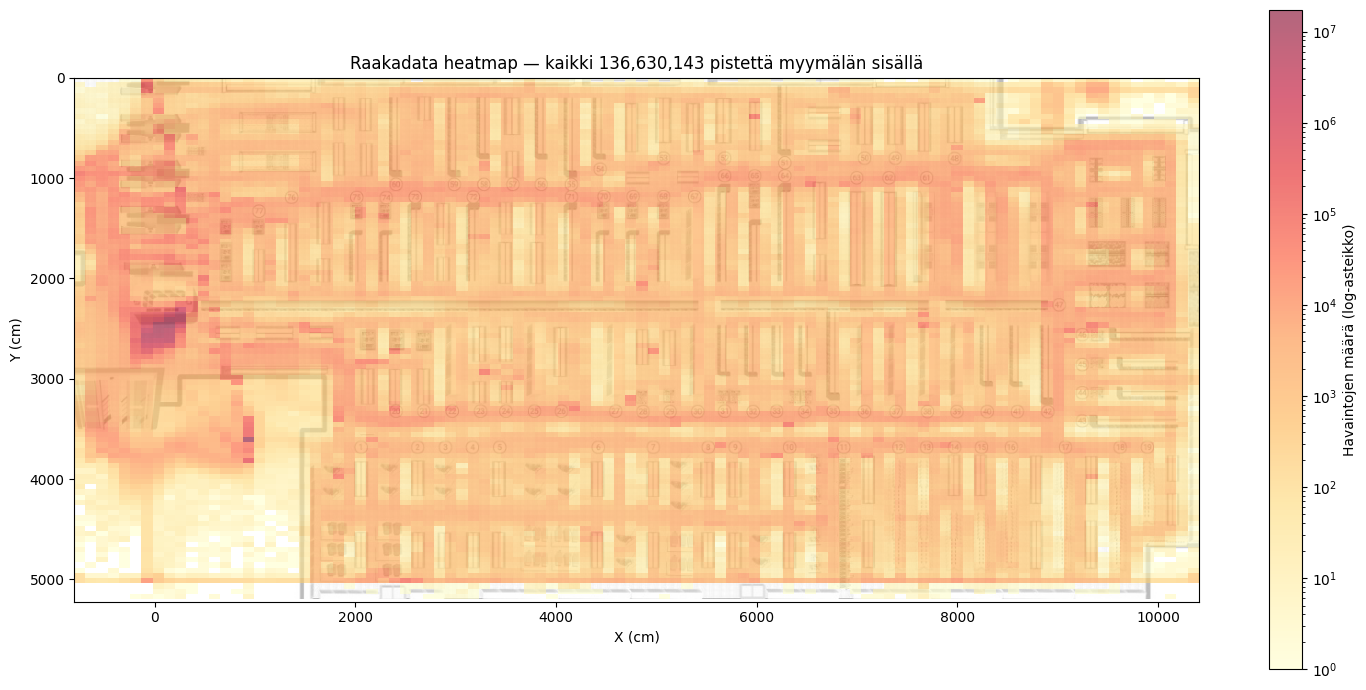

In [29]:
# Ladataan pohjakartta
img_path = os.path.join(project_root, "kauppa.jpg")
img = Image.open(img_path)
EXT = [img_x_min, img_x_max, img_y_max, img_y_min]

# Lasketaan 2D-histogrammi tiedosto kerrallaan
bins_x = np.linspace(img_x_min, img_x_max, 101)
bins_y = np.linspace(0, store_max_y, 101)
heatmap = np.zeros((100, 100))

for f in raw_files:
    df = pd.read_csv(
        f,
        usecols=["x", "y"],
        dtype={"x": float, "y": float}
    )
    
    inside = df[
         (df["x"] >= img_x_min) & (df["x"] <= img_x_max) &
         (df["y"] >= 0) & (df["y"] <= store_max_y)
    ]
    
    h, _, _ = np.histogram2d(inside["x"], inside["y"], bins=[bins_x, bins_y])
    heatmap += h.T
    
    del df, inside

print(f"Heatmap laskettu ✓")

# Piirretään
fig, ax = plt.subplots(figsize=(15, 7))

ax.imshow(img, extent=EXT, aspect="equal", alpha=0.5)

im = ax.imshow(
    heatmap,
    extent=EXT,
    origin="upper",
    cmap="YlOrRd",
    alpha=0.6,
    norm=LogNorm(),
    aspect="equal"
)

plt.colorbar(im, ax=ax, label="Havaintojen määrä (log-asteikko)")
ax.set_xlim(img_x_min, img_x_max)
ax.set_ylim(store_max_y, 0)
ax.set_xlabel("X (cm)")
ax.set_ylabel("Y (cm)")
ax.set_title(f"Raakadata heatmap — kaikki {total_inside:,} pistettä myymälän sisällä")
plt.tight_layout()
plt.show()

### Havainnot — raakadata vs siivottu data
- Raakadatassa 136 630 143 pistettä myymälän sisällä (x=0–10406, y=0–5220)
- Heatmapin yleiskuva vastaa siivottua dataa eli siivouksessa ei ole pudonnut mitään oleellista pois
- Kuumin piste koko myymälässä x≈0, y≈2500 eli sisään/uloskäynti ja info, koska jokainen kärry kulkee siitä.
- Käytävät erottuvat selkeästi
- Vasen reuna (kassalinja) selvästi vilkkaampi kuin oikea puoli
- Oikea yläkulma ei erotu kuumana alueena raakadatassa yhtä selkeästi kuin siivotun datan heatmapissa

### 6. Tutkitaan paljonko datassa on negatiivisia x-arvoja

In [9]:
# Tarkistetaan kuinka paljon dataa on negatiivisilla x-arvoilla
negative_x_count = 0
total_count = 0

for f in raw_files:
    df = pd.read_csv(
        f,
        usecols=["x"],
        dtype={"x": float}
    )
    negative_x_count += (df["x"] < 0).sum()
    total_count += len(df)
    del df

print(f"Pisteitä yhteensä: {total_count:,}")
print(f"Negatiivisia x-arvoja: {negative_x_count:,}")
print(f"Prosenttia: {round(negative_x_count / total_count * 100, 1)}%")

Pisteitä yhteensä: 139,961,560
Negatiivisia x-arvoja: 24,311,838
Prosenttia: 17.4%


### 6. Tutkitaan negatiivisten x-arvojen jakauma

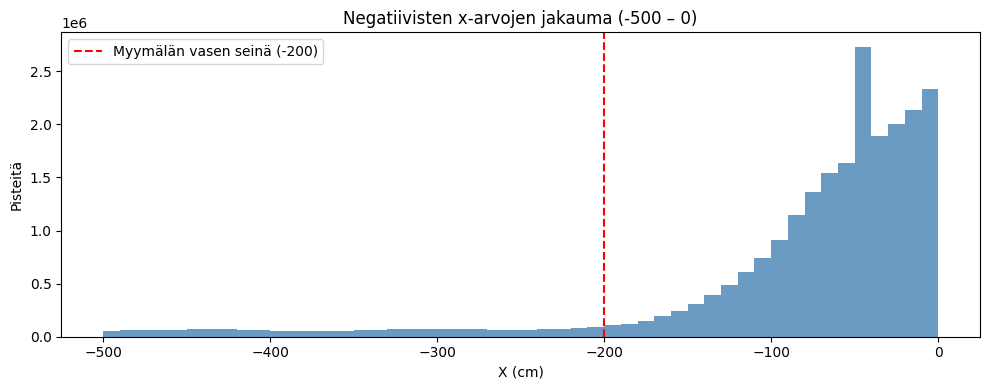

In [22]:
# Tutkitaan negatiivisten x-arvojen jakauma
bins_neg = np.linspace(-500, 0, 51)
counts_neg = np.zeros(50)

for f in raw_files:
    df = pd.read_csv(
        f,
        usecols=["x"],
        dtype={"x": float}
    )
    
    neg = df[(df["x"] >= -500) & (df["x"] < 0)]
    counts_neg += np.histogram(neg["x"], bins=bins_neg)[0]
    del df, neg

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(bins_neg[:-1], counts_neg, width=np.diff(bins_neg), color="steelblue", alpha=0.8, align="edge")
ax.set_xlabel("X (cm)")
ax.set_ylabel("Pisteitä")
ax.set_title("Negatiivisten x-arvojen jakauma (-500 – 0)")
ax.axvline(-200, color="red", linestyle="--", lw=1.5, label="Myymälän vasen seinä (-200)")
ax.legend()
plt.tight_layout()
plt.show()